In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
df = pd.read_csv("../../course_assignments/homework9/solar_system.csv")

In [3]:
print("shape:", df.shape)
print("number of rows:", df.shape[0])
print("number of columns:", df.shape[1])

shape: (20, 11)
number of rows: 20
number of columns: 11


In [4]:
df.head()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3


In [5]:
df.tail()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
15,Mean Temperature (C),167,464,15,-20,-65,-110,-140,-195,-200,-225
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown


In [11]:
print(df.columns)

Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')


In [14]:
print(df["Attribute"])

0                  Mass (10^24kg)
1                   Diameter (km)
2                Density (kg/m^3)
3                 Gravity (m/s^2)
4          Escape Velocity (km/s)
5         Rotation Period (hours)
6           Length of Day (hours)
7     Distance from Sun (10^6 km)
8            Perihelion (10^6 km)
9              Aphelion (10^6 km)
10          Orbital Period (days)
11        Orbital Velocity (km/s)
12      Orbital Inclination (deg)
13           Orbital Eccentricity
14       Obliquity to Orbit (deg)
15           Mean Temperature (C)
16        Surface Pressure (bars)
17                Number of Moons
18                   Ring System?
19         Global Magnetic Field?
Name: Attribute, dtype: object


In [18]:
orbital_period = df[df["Attribute"].str.contains("Orbital", case=False, na=False)].iloc[0,1:].astype(float)
perihelion = df[df["Attribute"].str.contains("Perihelion", case=False, na=False)].iloc[0,1:].astype(float)
aphelion = df[df["Attribute"].str.contains("Aphelion", case=False, na=False)].iloc[0,1:].astype(float)

Perihelion is the closest point of a planet's orbit to the Sun.
Aphelion is the farthest point of a planet's orbit from the Sun.
The semi-major axis is half of the longest width of the orbit.

In [19]:
semi_major_axis = (perihelion + aphelion) / 2

In [22]:
new_row = pd.DataFrame([["Semi_major axis (10^6 km)"] + semi_major_axis.tolist()], columns=df.columns)
new_df = pd.concat([df, new_row], ignore_index=True)

In [23]:
print("shape:", new_df.shape)
print("number of rows:", new_df.shape[0])
print("number of columns:", new_df.shape[1])

shape: (21, 11)
number of rows: 21
number of columns: 11


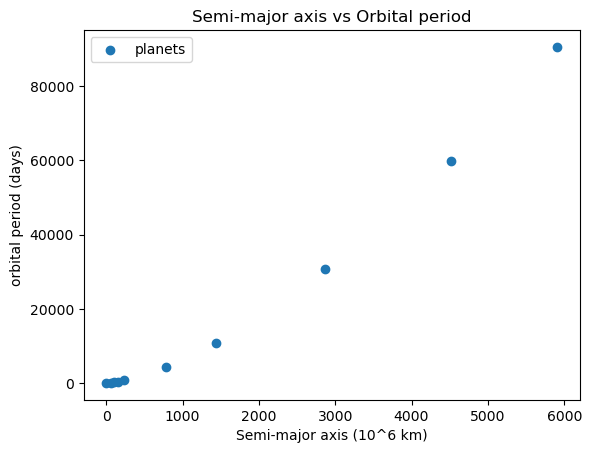

In [24]:
plt.scatter(semi_major_axis, orbital_period, label="planets")

plt.title("Semi-major axis vs Orbital period")
plt.xlabel("Semi-major axis (10^6 km)")
plt.ylabel("orbital period (days)")

plt.legend()
plt.show()

In [25]:
def keplers_third_law(a, m):
    return m * a ** 1.5

In [27]:
a = semi_major_axis.values
T = orbital_period.values

popt, pcov = curve_fit(keplers_third_law, a, T, p0=[1])

In [30]:
m_fit = popt[0]

In [31]:
print(f"T = {m_fit:.2f} * a^(1.5)")

T = 0.20 * a^(1.5)


In [35]:
residuals = T - keplers_third_law(a, m_fit)
chi2 = np.sum(residuals**2)
dof = len(a) - len(popt)
chi2_reduced = chi2 / dof

print(f"reduced chi-squared: {chi2_reduced:.2f}")

reduced chi-squared: 41276.71


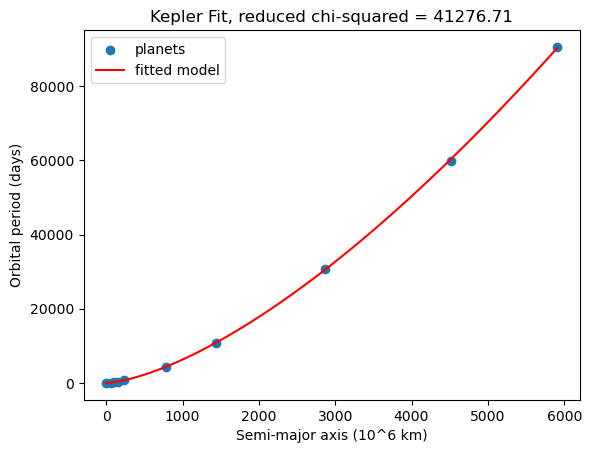

In [39]:
a_fit = np.linspace(a.min(), a.max(), 300)

plt.scatter(a, T, label="planets")
plt.plot(a_fit, keplers_third_law(a_fit, m_fit), color="red", label="fitted model")

plt.title(f"Kepler Fit, reduced chi-squared = {chi2_reduced:.2f}")
plt.xlabel("Semi-major axis (10^6 km)")
plt.ylabel("Orbital period (days)")
plt.legend()
plt.show()

In [40]:
new_df.to_csv("kepler.csv", index=False)